In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('figure',  figsize=(20, 10))
mpl.rc('image', cmap='gray')

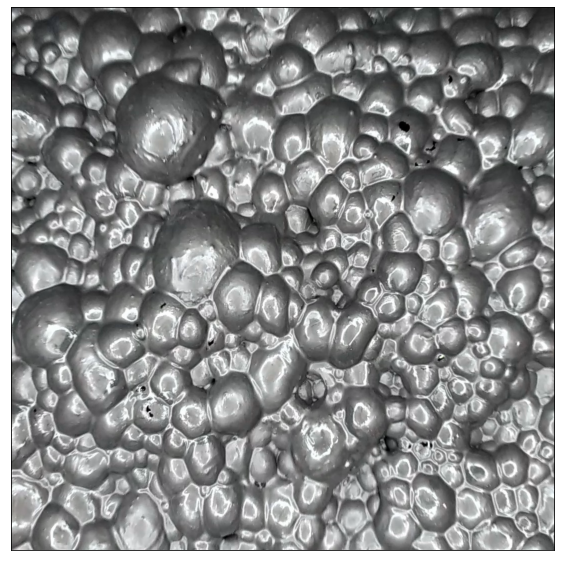

In [99]:
image = cv2.imread("/content/sample_data/bubble_raw.png")

plt.imshow(image)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

In [12]:
# Apply median filter and adaptive threshold to original image
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
median = cv2.medianBlur(image, 3)
_, thresh = cv2.threshold(median, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

In [25]:
thresh.shape

(1088, 1088)

In [13]:
# Extract white spots by identifying round objects in processed image
white_spots = cv2.HoughCircles(thresh, cv2.HOUGH_GRADIENT, 1, 20, param1=50, param2=30, minRadius=0, maxRadius=0)

In [33]:
  # Apply size filter to remove unwanted (very small) objects
  min_size = 3
  white_spots = [spot for spot in white_spots if spot[2] > min_size]
  

array([553.86865, 399.9425 , 423.88004, ..., 616.7315 , 168.5521 ,
       234.59781], dtype=float32)

In [42]:
# Compute mean size and number of extracted white spots
mean_size = sum([spot[2] for spot in white_spots]) / len(white_spots[0])
num_spots = len(white_spots[0])

In [43]:
print(mean_size)
print(num_spots)

0.349447679637585
1213


In [45]:
# Use white spot size and number as input features for neural network classifier
froth_type = 7


In [95]:
# Update size of pre-median filter and determine size of post-median filter based on froth type
pre_median_size = 7
post_median_size = 7

In [53]:
# Apply new pre-median filter and adaptive threshold
median = cv2.medianBlur(image, pre_median_size)
_, thresh = cv2.threshold(median, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

In [68]:
# Extract first set of markers by identifying round objects in processed image
#markers1 = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
markers1 = cv2.HoughCircles(thresh, cv2.HOUGH_GRADIENT, 1, 20, param1=50, param2=30, minRadius=0, maxRadius=0)

In [81]:
# Check if circles were detected
if markers1 is not None:
    # Convert the circles to integers
    markers1 = np.round(markers1).astype("int")

    # # Loop through the detected circles
    # for (x, y, r) in markers1:
    #     # Draw the circle on the image
    #     cv2.circle(image, (x, y), r, (0, 255, 0), 4)


In [69]:
# Smooth original image and extract second and third sets of markers using morphological operators
smooth = cv2.GaussianBlur(image, (5,5), 0)
markers2 = cv2.erode(smooth, None, iterations=3)
markers3 = cv2.dilate(smooth, None, iterations=3)

In [90]:
circles = np.uint16(np.around(markers1))
markers1_img = np.zeros_like(markers2, dtype=np.uint8)
for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(markers1_img,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    #cv.circle(cimg,(i[0],i[1]),2,(0,0,255),3)

In [96]:
# Combine all sets of markers and apply post-median filter
markers = cv2.bitwise_or(markers1_img, markers2)
markers = cv2.bitwise_or(markers, markers3)

markers = cv2.medianBlur(markers, post_median_size)

In [66]:
print(markers2.shape)

(1088, 1088)


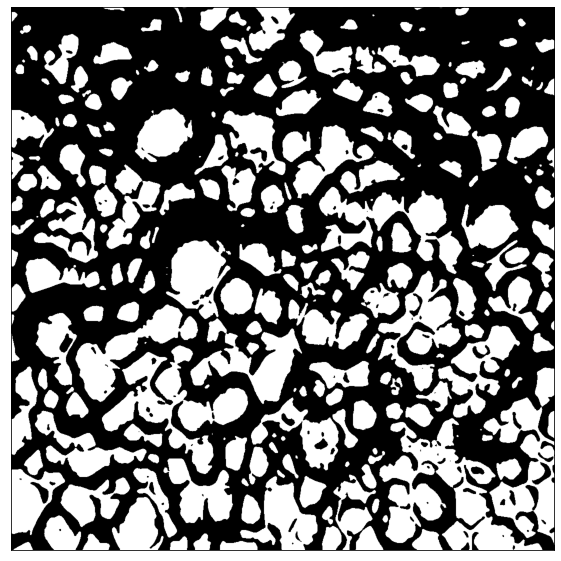

In [107]:
plt.imshow(markers)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

In [108]:
image_8u = cv2.normalize(markers, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

In [109]:
# Invert processed image and apply watershed transform to smoothed topographic surface
inverted = cv2.bitwise_not(thresh)
smooth = cv2.GaussianBlur(inverted, (3,3), 0)
_, markers = cv2.connectedComponents(image_8u)
markers += 1
markers[inverted==255] = 0
markers = cv2.watershed(image, markers)

# Create output image with different colors for each catchment basin
image[markers == -1] = [255,0,0]
image[markers > 0] = [0,255,0]

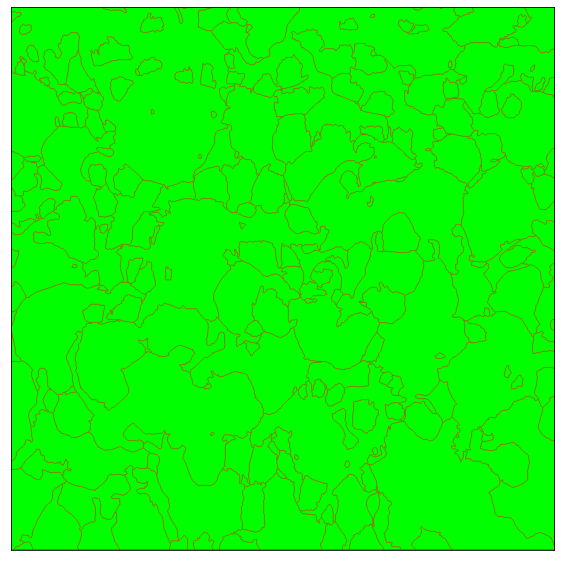

In [110]:
plt.imshow(image)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()